# Приступим к работе :)

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from scipy.spatial.distance import directed_hausdorff
from skimage.exposure import histogram
from skimage._shared.utils import warn
from skimage.filters._multiotsu import (_get_multiotsu_thresh_indices)
import time

### Загрузка изображения

Тип изображения: <class 'numpy.ndarray'>, форма: (640, 640)


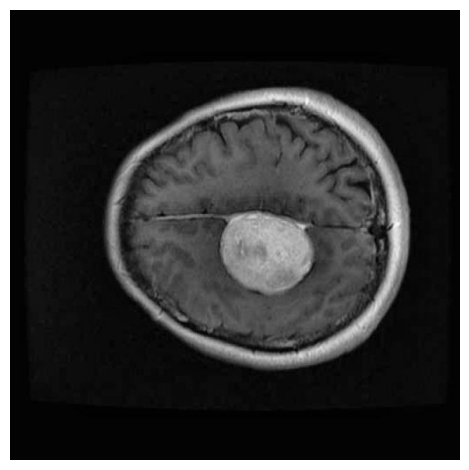

In [85]:
image_path = "../static/GA_csv/images/brain12.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

assert image is not None, "Изображение не загружено"
print(f"Тип изображения: {type(image)}, форма: {image.shape}")

# Настройка фигуры для отображения
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off') # Отключаем оси
# Отображаем изображения
plt.tight_layout() 
plt.show()

image = cv2.GaussianBlur(image, (5, 5), 0)

### Реализация функций предобработки и многопороговой сегментации изображения  

Реализуются методы для сегментации изображений с использованием многопороговых подходов. Применяется алгоритм Оцу и генетический алгоритм.  

**Алгоритм Оцу** (Otsu's method) — это метод автоматического выбора оптимального порога для бинаризации (разделения на чёрное и белое) или многопороговой сегментации  изображения. Он максимизирует межклассовую дисперсию (разницу между группами пикселей) или минимизирует внутриклассовую дисперсию (разброс внутри групп).  

> *Алгоритм Оцу* — это метод автоматической бинаризации изображений, который находит оптимальный порог для разделения изображения на два класса: фон и объект.  

**Multi-Otsu** — это расширение алгоритма Оцу, которое разделяет изображение на больше, чем два класса, то есть на несколько диапазонов значений интенсивности (например, фон, тени, объекты).  

Данный алгоритм строит гистограмму яркости изображения. Затем перебирает все возможные пороги, вычисляя насколько хорошо разделились пиксели на классы (фон, объекты). Далее выбирается порог, который максимально разделяет гистограмму на отдельные пики.  

Удобно применять для Сегментации медицинских изображений (МРТ, КТ, рентген), для выделения объектов на фоне, для автоматической бинаризации (для распознавания текста)

### Метрики  

Метрики для оценки качества сегментации изображения. Насколько точно сегментированное изображение совпадает с эталонной (ручной) разметкой.  

*Dice coefficient* (Коэффициент Соренсена-Дайса): Формула: 2 * (пересечение) / (сумма пикселей в обоих масках)  
Значения: от 0 (нет совпадений) до 1 (идеальное совпадение).

Jaccard Index (Индекс Жаккара / IoU): Формула: (пересечение) / (объединение)  
Также от 0 до 1. Более строгий, чем Dice.  

Эти метрики используют, чтобы сравнивать маску сегментации (результат) с эталоном (ground truth).

##### Пояснения
**PSNR (Peak Signal-to-Noise Ratio)** - отношение пикового сигнала к шуму. Метрика для оценки качества реконструкции изображений.  

**IoU (Intersection over Union)** - пересечение по объединению, то же самое, что Jaccard Index, используется для детекции объектов.  

**Ground Truth** - "истинные" данные, размеченные вручную.  

**Segmentation_mask** - маска сегментации. Бинарное или многоклассовое изображение, где каждый пиксель принадлежит к определённому классу.

In [86]:
# === ===== ===== ===== ===
# Метрики качества сегментации
# === ===== ===== ===== ===

# Dice Coefficient (Коэффициент Dice / F1-Score) как мера сходства между 2 наборами данных.
def dice_coefficient(segmentation_mask, ground_truth_mask):
    # Пересечение масок. Сходство между предсказанием и истинной (эталонной) масками (диапазоны 0, 1). В сегментации медицинских изображений.
    intersection = np.logical_and(segmentation_mask, ground_truth_mask)
    return 2.0 * intersection.sum() / (segmentation_mask.sum() + ground_truth_mask.sum())


# Jaccard Index (Индекс Жаккара / IoU — Intersection over Union)
def jaccard_index(segmentation_mask, ground_truth_mask):
    # Пересечение масок. Перекрытие между масками, строгая метрика, чувствительна к ложным срабатываниям (диапозон 0, 1)
    intersection = np.logical_and(segmentation_mask, ground_truth_mask)
    # Объединение масок
    union = np.logical_or(segmentation_mask, ground_truth_mask)
    return intersection.sum() / union.sum()


# Sorensen-Dice Coefficient (Коэффициент Соренсена-Кости)
def sorensen_dice_coefficient(segmentation_mask, ground_truth_mask):
    # Фактически идентичен Dice. Измеряет насколько хорошо 2 бинарные маски совпадают друг с другом. Лучшедля несбалансированых классов
    intersection = np.logical_and(segmentation_mask, ground_truth_mask)
    return 2.0 * intersection.sum() / (segmentation_mask.sum() + ground_truth_mask.sum())


# Валидация, подготовка гистограммы изображения
def _validate_image_histogram(image, hist, nbins=None, normalize=False):
    if image is None and hist is None:
        raise Exception("Необходимо предоставить либо изображение, либо гистограмму.")
    
    if hist is not None:
        if isinstance(hist, (tuple, list)):
            # Распаковка гистограммы
            counts, bin_centers = hist
        else:
            counts = hist
            # Автоматические центры бинов
            bin_centers = np.arange(counts.size)

        # Обрезка нулевых краёв гистограммы
        if counts[0] == 0 or counts[-1] == 0:
            # Маска ненулевых значений
            cond = counts > 0
            # Первый ненулевой бин
            start = np.argmax(cond)
            # Последний ненулевой бин
            end = cond.size - np.argmax(cond[::-1])
            counts, bin_centers = counts[start:end], bin_centers[start:end]
    else:
        # Построение гистограммы из изображения
        counts, bin_edges = histogram(image.reshape(-1), nbins, source_range='image', normalize=normalize)
        # Вычисление центров бинов
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    return counts.astype('float32', copy=False), bin_centers


# ==================================
# МНОГОПОРОГОВЫЙ МЕТОД ОЦУ
# ==================================

# Многопороговый метод ОЦУ для сегментации
def threshold_multiotsu(image=None, classes=4, nbins=512, *, hist=None):
    # classes - количество классов для сегментации. nbins - количество бинов гистограммы. hist - возможность передать готовую гистограмму
    # Начать отсчёт времени
    start_time = time.time()

    # Проверка на EGB изображение (метод работает только с grayscale)
    if image is not None and image.ndim > 2 and image.shape[-1] in (3, 4):
        warn(f'ожидается, что параметр threshold_multi otsu будет корректно работать только для изображений в оттенках серого;'
             f'форма изображения {image.shape} похожа на изображение в формате RGB.')
        
    # Получение гистограммы и вероятностей каждого уровня серого
    prob, bin_centers = _validate_image_histogram(image, hist, nbins, normalize=True)
    prob = prob.astype('float32', copy=False)

    # Проверка достаточности уникальных значений
    nvalues = np.count_nonzero(prob)
    if nvalues < classes:
        message = (f'После дискретизации по ячейкам входное изображение содержит только {nvalues} различных значений. В классах {classes}' 
                   f'не может быть установлен порог. Если до дискретизации было больше уникальных значений, попробуйте увеличить количество ячеек (`nbins`).')
        raise ValueError(message)
    elif nvalues == classes:
        # Индексы ненулевых значений
        thresh_idx = np.flatnonzero(prob)[:-1]
    else:
        # Получить пороговые индексы. Основная работа метода Оцу (поиск оптимальных порогов)
        thresh_idx = _get_multiotsu_thresh_indices(prob, classes - 1)

    # Остановить отсчет времени
    end_time = time.time()
    print("Время, необходимое для работы функции multi otsu:", end_time - start_time, "секунды")

    # Возвращение пороговых значений (в оригинальной шкале яркости)
    thresh = bin_centers[thresh_idx]
    return thresh


# Применение порогов
def apply_multiotsu_thresholds(image, thresholds):
    # Применение нескольких порогов к изображению. Результат - изображение, где каждый сегмент имеет значение пропорциональное его классу.
    # Пустая маска 
    result = np.zeros_like(image)
    for i in range(len(thresholds)):
        # Пиксели выше порога получают значение (i+1)/N * 255
        result[image > thresholds[i]] = 255 * (i + 1) / len(thresholds)
    return result

## Что такое генетический алгоритм?  

**Генетический алгоритм (ГА)** — это метод оптимизации, вдохновлённый естественным отбором. Он использует:  
1. Популяцию возможных решений (например, пороги сегментации), 
2. Оценку приспособленности (fitness function), 
3. Скрещивание (crossover) — обмен "генами" между решениями, 
4. Мутации (mutation) — случайные изменения.  
Алгоритм выбирает лучшие решения, комбинирует их и повторяет процесс, приближаясь к оптимальному результату.  

**Генетический алгоритм (Genetic Algorithm, GA)** — это эволюционный метод оптимизации, вдохновленный естественным отбором. Он имитирует:  
* Популяцию (набор возможных решений).
* Селекцию (отбор лучших решений).
* Кроссинговер (обмен признаками между решениями).
* Мутации (случайные изменения).

*Как работает это?*  
* Инициализация: Создает случайные пороги (population).
* Оценка (Fitness): Использует PSNR (пиковое отношение сигнал/шум) для оценки качества сегментации.
* Селекция: Отбирает лучшие пороги.
* Кроссинговер: Объединяет пороги двух "родителей".
* Мутация: Случайно изменяет некоторые пороги.
* Повторение: Процесс повторяется несколько поколений (num_generations).

*Применяется*  
Когда метод Оцу работает плохо (например, при сложных гистограммах). Для нахождения нескольких порогов (многоклассовая сегментация). Когда нужна глобальная оптимизация, а не локальная.  

**Особенности генетического алгоритма:**
> ГА по умолчанию максимизирует fitness-функцию или функцию приспособленности (ищет особь с наибольшим значением). PSNR — это метрика, которую мы хотим максимизировать (чем выше PSNR, тем лучше качество), поскольку в нашем случае мы хотим, чтобы качество ошибки было минимальным (чем выше PSNR, тем лучше совпадение).

Проблема:  
Если напрямую использовать PSNR как fitness, ГА будет его максимизировать — это правильно.

In [87]:
# ======================================
# ГЕНЕТИЧЕСКИЙ АЛГОРИТМ
# ======================================

# Фитнесс-функция. Функция приспособленности для генетического алгоритма.
def fitness_function(thresholds, image, ground_truth=None):
    # Использует PSNR (Peak Signal-to-Noise Ratio) мера качества. Чем ближе сегментированное изображение к оригиналу, тем лучше (по PSNR)
    segmented = apply_multiotsu_thresholds(image, thresholds)
    
    # Комбинированная метрика
    psnr_score = psnr(image, segmented)
    
    if ground_truth is not None:
        dice_score = dice_coefficient(segmented, ground_truth)
        jaccard_score = jaccard_index(segmented, ground_truth)
        return 0.4 * psnr_score + 0.3 * dice_score + 0.3 * jaccard_score
    else:
        return psnr_score


# Селекция. Отбор 2 лучших особей
def selection(population, fitness_scores):
    # Сортировка по качеству
    sorted_indices = np.argsort(fitness_scores)
    # Лучшие две особи
    return population[sorted_indices[-2:]], fitness_scores[sorted_indices[-2:]]


# Кроссинговер. Создание потомков из 2 родителей.
def crossover(parents):
    # Случайная точка раздела
    crossover_point = np.random.randint(1, len(parents[0]))
    child1 = np.concatenate((parents[0][:crossover_point], parents[1][crossover_point:]))
    child2 = np.concatenate((parents[1][:crossover_point], parents[0][crossover_point:]))
    return child1, child2


# Мутация. Случайное изменение порогов с вероятностью.
def mutation(child, mutation_rate):
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            # Случайное значение яркости
            child[i] = np.random.randint(0, 255)
    return child


# Основная функция Генетического алгоритма (ГА)
def genetic_algorithm(image, num_thresholds, population_size=8, num_generations=15, mutation_rate=0.25):
    # num_thresholds - количество искомых порогов. population_size - размер популяции. num_generations - количество поколений. mutation_rate - вероятность мутации
    start_time = time.time()
    # Инициализация популяции (случайные пороги)
    population = np.random.randint(0, 255, size=(population_size, num_thresholds))
    
    # Эволюционный процесс
    for generation in range(num_generations):
        # Оценка качества каждой особи
        fitness_scores = np.array([fitness_function(thresholds, image) for thresholds in population])
        # Селекция
        selected_population, selected_fitness = selection(population, fitness_scores)
        new_population = []

        # Создание нового поколения
        for _ in range(population_size // 2):
            # Выбор родителей (случайно из лучших)
            parents = selected_population[np.random.choice(range(len(selected_population)), size=2, replace=False)]

            # Кроссинговер и мутация
            child1, child2 = crossover(parents)
            child1 = mutation(child1, mutation_rate)
            child2 = mutation(child2, mutation_rate)

            new_population.extend([child1, child2])
        population = np.array(new_population)
    
    # Получение лучшего решения
    best_thresholds = population[np.argmax(fitness_scores)]
    end_time = time.time()
    print("Время, затраченное на оптимизацию генетического алгоритма: ", end_time - start_time, "секунды")
    return np.sort(best_thresholds)

### Пороговое значение для нескольких otsu без фильтрации

Время, необходимое для работы функции multi otsu: 0.07475638389587402 секунды


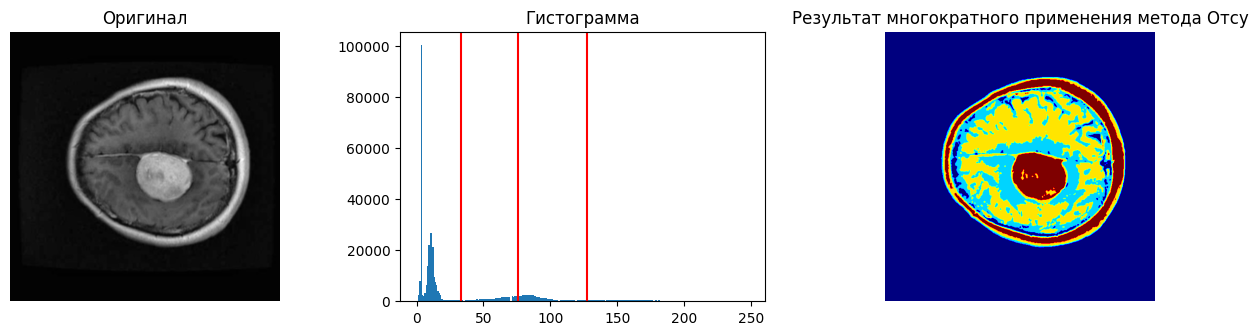

In [88]:
# Вычислить пороговые значения для нескольких Otsu
thresholds = threshold_multiotsu(image)

# Сегментируйте изображение на разные области
regions = np.digitize(image, bins=thresholds)

# Отображение исходного изображения, гистограммы и результата с несколькими отсчетами
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 3.5))

# Исходное изображение
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Оригинал')
ax[0].axis('off')

# Гистограмма с пороговыми линиями
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Гистограмма')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Результат многократного применения метода Отсу
ax[2].imshow(regions, cmap='jet')  
ax[2].set_title('Результат многократного применения метода Отсу')
ax[2].axis('off')

plt.subplots_adjust()
plt.show()

### Расчёт метрик

In [89]:
# Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient
psnr_value = psnr(image, regions, data_range=255)
ssim_value = ssim(image, regions, data_range=255)
dsc_value = dice_coefficient(image, regions)
ji_value = jaccard_index(image, regions)

# Вывод значений
print("the psnr : ",psnr_value)
print("the ssim : ",ssim_value)
print("Dice Similarity Coefficient : ", dsc_value)
print("Jaccard Index : ", ji_value)

the psnr :  12.804429198497482
the ssim :  0.14309644651655729
Dice Similarity Coefficient :  0.017528914079239587
Jaccard Index :  0.32286448109844823


#### Пороговое значение с несколькими отсчетами с медианным фильтром

Время, необходимое для работы функции multi otsu: 0.07079458236694336 секунды
Время, необходимое для работы функции multi otsu: 0.025064706802368164 секунды


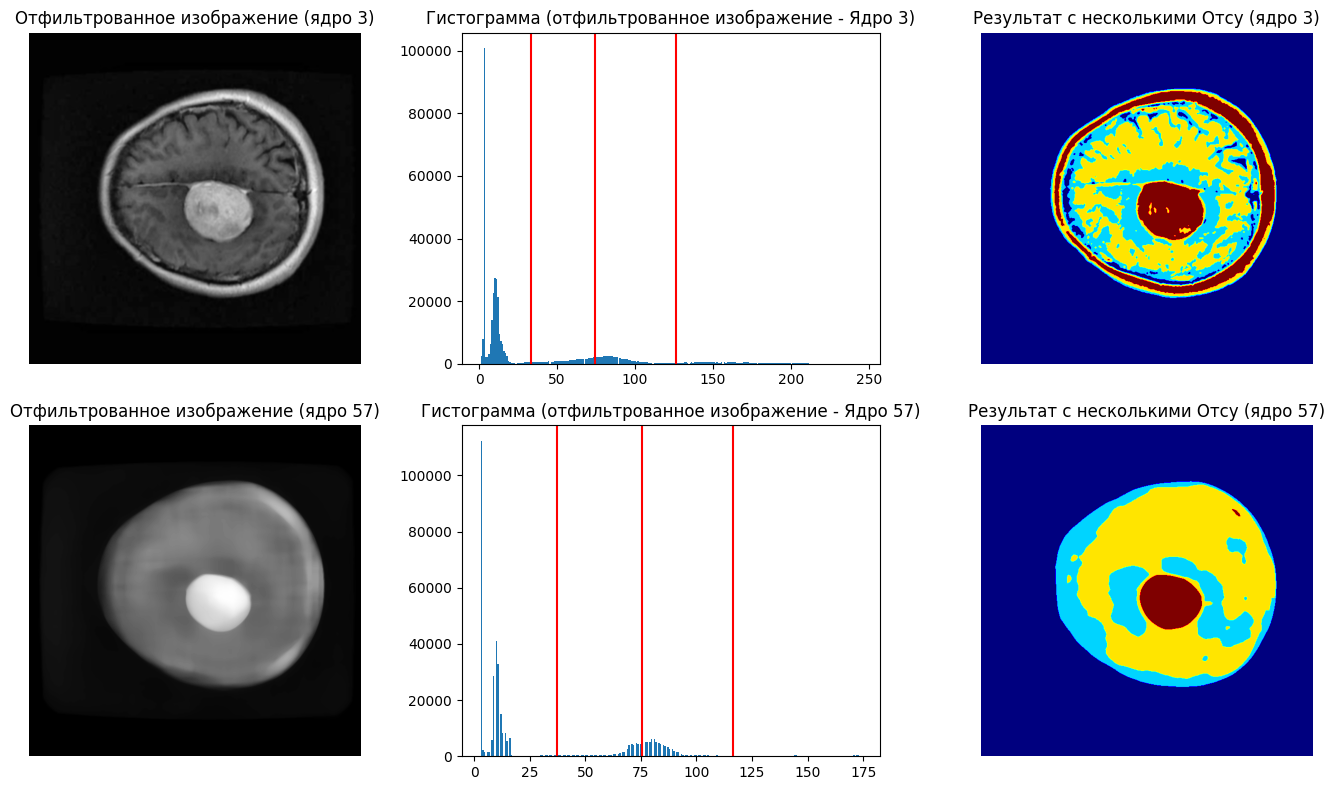

In [90]:
# Примените фильтры
image_filtre_3 = cv2.medianBlur(image, 3)
image_filtre_57 = cv2.medianBlur(image, 57)

# Вычисление пороговых значений для нескольких Otsu
thresholds = threshold_multiotsu(image_filtre_3, classes=4)
thresholdss = threshold_multiotsu(image_filtre_57, classes=4)


# Разделите изображения на разные области
regions = np.digitize(image_filtre_3, bins=thresholds)
regionss = np.digitize(image_filtre_57, bins=thresholds)


# Отображение отфильтрованных изображений, гистограмм и результатов с несколькими отсчетами
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))

# Отфильтрованные изображения
axes[0, 0].imshow(image_filtre_3, cmap='gray')
axes[0, 0].set_title('Отфильтрованное изображение (ядро 3)')
axes[0, 0].axis('off')

axes[1, 0].imshow(image_filtre_57, cmap='gray')
axes[1, 0].set_title('Отфильтрованное изображение (ядро 57)')
axes[1, 0].axis('off')

# Гистограммы с пороговыми линиями
axes[0, 1].hist(image_filtre_3.ravel(), bins=255)
for thresh in thresholds:
    axes[0, 1].axvline(thresh, color='r')
axes[0, 1].set_title('Гистограмма (отфильтрованное изображение - Ядро 3)')

axes[1, 1].hist(image_filtre_57.ravel(), bins=255)
for thresh in thresholdss:
    axes[1, 1].axvline(thresh, color='r')
axes[1, 1].set_title('Гистограмма (отфильтрованное изображение - Ядро 57)')

# Результаты Multi-Otsu
axes[0, 2].imshow(regions, cmap='jet')
axes[0, 2].set_title('Результат с несколькими Отсу (ядро 3)')
axes[0, 2].axis('off')

axes[1, 2].imshow(regionss, cmap='jet')
axes[1, 2].set_title('Результат с несколькими Отсу (ядро 57)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Расчёт метрик

In [91]:
# Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient для отфильтрованного изображения с ядром 3*3
psnr_value = psnr(image, regions, data_range=255)
ssim_value = ssim(image, regions, data_range=255)
dsc_value = dice_coefficient(image, regions)
ji_value = jaccard_index(image, regions)

# Вывод для ядра 3*3
print(" ********* Для Ядра 3*3 ********* \n")

# Вывод значений
print("the psnr : ", psnr_value)
print("the ssim : ", ssim_value)
print("Dice Similarity Coefficient : ", dsc_value)
print("Jaccard Index : ", ji_value)
print()

# Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient для отфильтрованного изображения с ядром 57*57
psnr_valuee = psnr(image, regionss, data_range=255)
ssim_valuee = ssim(image, regionss, data_range=255)
dsc_valuee = dice_coefficient(image, regionss)
ji_valuee = jaccard_index(image, regionss)

# Вывод для ядра  57*57
print(" ********* Для Ядра 57*57 ********* ")
print()

# Вывод значений
print("the psnr : ", psnr_valuee)
print("the ssim : ", ssim_valuee)
print("Dice Similarity Coefficient : ", dsc_valuee)
print("Jaccard Index : ", ji_valuee)

 ********* Для Ядра 3*3 ********* 

the psnr :  12.805714195635279
the ssim :  0.143191966065162
Dice Similarity Coefficient :  0.017549402505012808
Jaccard Index :  0.3232990556548404

 ********* Для Ядра 57*57 ********* 

the psnr :  12.779531454209422
the ssim :  0.1436656544760247
Dice Similarity Coefficient :  0.017772891637902636
Jaccard Index :  0.3271174523188703


### Пороговое значение с несколькими отсчетами с фильтром среднего значения

Время, необходимое для работы функции multi otsu: 0.07660603523254395 секунды
Время, необходимое для работы функции multi otsu: 0.02501678466796875 секунды


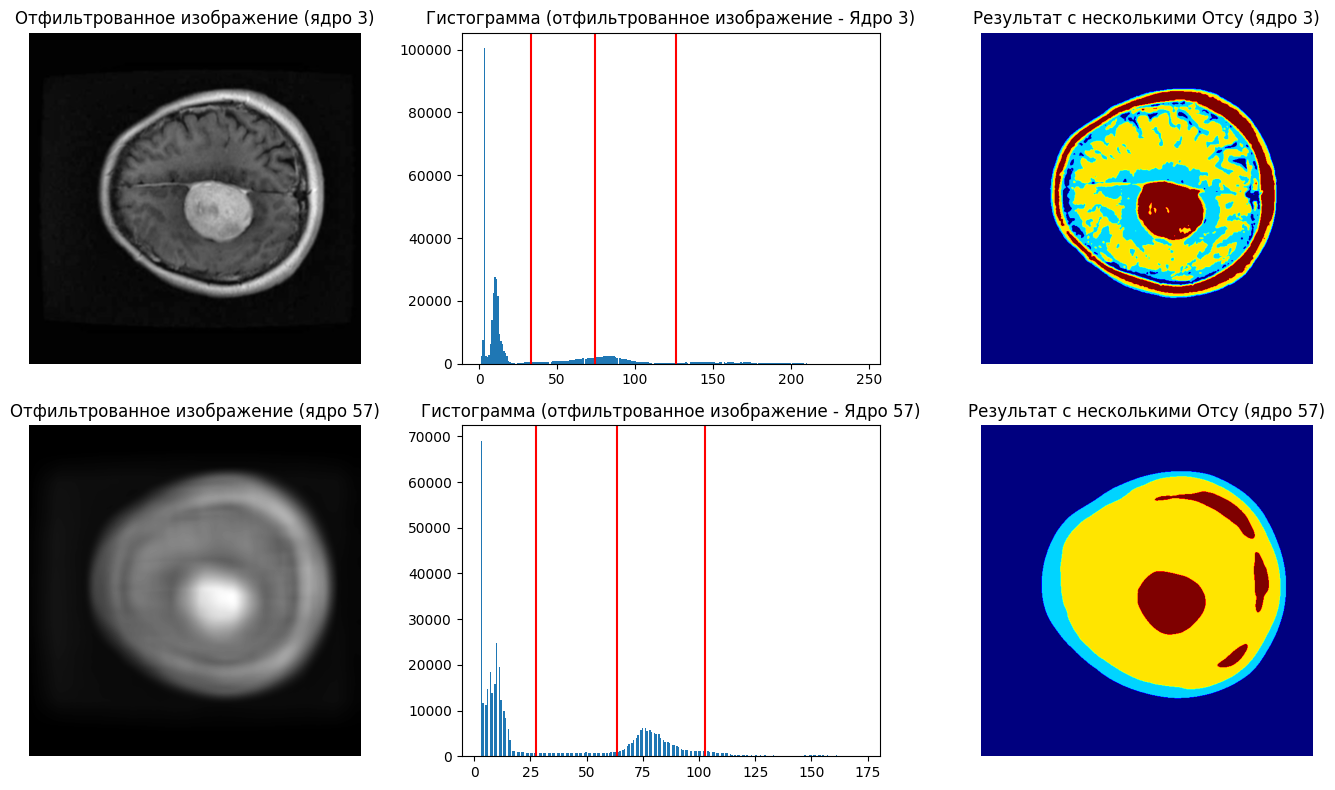

In [92]:
# Определение средних ядер фильтров
mean_kernel_3 = np.ones((3, 3), np.float32) / 9
mean_kernel_57 = np.ones((57, 57), np.float32) / (57 * 57)

# Применить среднюю фильтрацию
mean_filtered_image_3 = cv2.filter2D(image, -1, mean_kernel_3)
mean_filtered_image_57 = cv2.filter2D(image, -1, mean_kernel_57)

# Вычисление пороговых значений для нескольких Otsu
thresholds = threshold_multiotsu(mean_filtered_image_3, classes=4)
thresholdss = threshold_multiotsu(mean_filtered_image_57, classes=4)

# Сегментируйте изображение на разные области
regions = np.digitize(mean_filtered_image_3, bins=thresholds)
regionss = np.digitize(mean_filtered_image_57, bins=thresholdss)

# Отображение отфильтрованных изображений, гистограмм и результатов с несколькими отсчетами
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))

# Отфильтрованные изображения
axes[0, 0].imshow(mean_filtered_image_3, cmap='gray')
axes[0, 0].set_title('Отфильтрованное изображение (ядро 3)')
axes[0, 0].axis('off')

axes[1, 0].imshow(mean_filtered_image_57, cmap='gray')
axes[1, 0].set_title('Отфильтрованное изображение (ядро 57)')
axes[1, 0].axis('off')

# Гистограммы с пороговыми линиями
axes[0, 1].hist(mean_filtered_image_3.ravel(), bins=255)
for thresh in thresholds:
    axes[0, 1].axvline(thresh, color='r')
axes[0, 1].set_title('Гистограмма (отфильтрованное изображение - Ядро 3)')

axes[1, 1].hist(mean_filtered_image_57.ravel(), bins=255)
for thresh in thresholdss:
    axes[1, 1].axvline(thresh, color='r')
axes[1, 1].set_title('Гистограмма (отфильтрованное изображение - Ядро 57)')

# Результаты Multi-Otsu
axes[0, 2].imshow(regions, cmap='jet')
axes[0, 2].set_title('Результат с несколькими Отсу (ядро 3)')
axes[0, 2].axis('off')

axes[1, 2].imshow(regionss, cmap='jet')
axes[1, 2].set_title('Результат с несколькими Отсу (ядро 57)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Расчёт метрик

In [93]:
# Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient для отфильтрованного изображения с ядром 3*3
psnr_value = psnr(image, regions, data_range=255)
ssim_value = ssim(image, regions, data_range=255)
dsc_value = dice_coefficient(image, regions)
ji_value = jaccard_index(image, regions)

# Вывод для ядра 3*3
print(" ********* Для Ядра 3*3 ********* \n")

# Вывод значений
print("the psnr : ", psnr_value)
print("the ssim : ", ssim_value)
print("Dice Similarity Coefficient : ", dsc_value)
print("Jaccard Index : ", ji_value)
print()

# Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient для отфильтрованного изображения с ядром 57*57
psnr_valuee = psnr(image, regionss, data_range=255)
ssim_valuee = ssim(image, regionss, data_range=255)
dsc_valuee = dice_coefficient(image, regionss)
ji_valuee = jaccard_index(image, regionss)

# Вывод для ядра  57*57
print(" ********* Для Ядра 57*57 ********* ")
print()

# Вывод значений
print("the psnr : ", psnr_valuee)
print("the ssim : ", ssim_valuee)
print("Dice Similarity Coefficient : ", dsc_valuee)
print("Jaccard Index : ", ji_valuee)

 ********* Для Ядра 3*3 ********* 

the psnr :  12.805706747643377
the ssim :  0.14319819944924556
Dice Similarity Coefficient :  0.01760459974353986
Jaccard Index :  0.3243220148634264

 ********* Для Ядра 57*57 ********* 

the psnr :  12.809820216424164
the ssim :  0.15459898502431835
Dice Similarity Coefficient :  0.02115125452994921
Jaccard Index :  0.39132462231076476


In [94]:
num_thresholds = 5

### Генетический алгоритм без фильтра

Время, необходимое для работы функции multi otsu: 3.135219097137451 секунды
Время, затраченное на оптимизацию генетического алгоритма:  0.5892517566680908 секунды


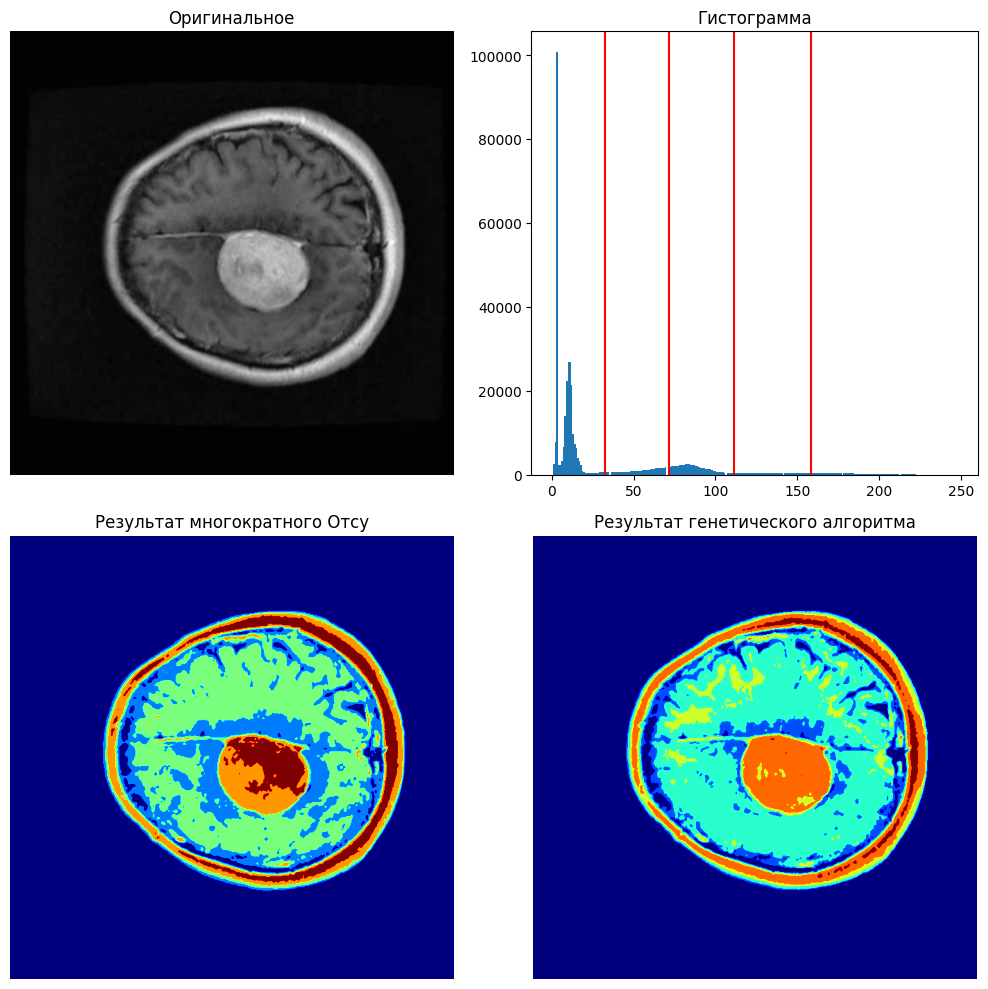

In [95]:
# Вычисление пороговых значений для нескольких Otsu
thresholds = threshold_multiotsu(image, classes=num_thresholds)

# Запустите генетический алгоритм для уточнения пороговых значений
best_thresholds = genetic_algorithm(image, num_thresholds)

# Примените пороговые значения к изображению
thresholded_image_multiotsu = apply_multiotsu_thresholds(image, thresholds)
thresholded_image_genetic = apply_multiotsu_thresholds(image, best_thresholds)

# Отобразите исходное изображение, гистограмму, результат множественного Отсу и генетический результат
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# Исходное изображение
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Оригинальное')
ax[0, 0].axis('off')

# Гистограмма с пороговыми линиями
ax[0, 1].hist(image.ravel(), bins=255)
ax[0, 1].set_title('Гистограмма')
for thresh in thresholds:
    ax[0, 1].axvline(thresh, color='r')

# Результат многократного Отсу
ax[1, 0].imshow(thresholded_image_multiotsu, cmap='jet')  
ax[1, 0].set_title('Результат многократного Отсу')
ax[1, 0].axis('off')

# Результат генетического алгоритма
ax[1, 1].imshow(thresholded_image_genetic, cmap='jet')  
ax[1, 1].set_title('Результат генетического алгоритма')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Расчёт метрик

In [96]:
# Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient для отфильтрованного изображения с ядром 3*3
psnr_value = psnr(image, thresholded_image_genetic)
ssim_value = ssim(image, thresholded_image_genetic)
dsc_value = dice_coefficient(image, thresholded_image_genetic)
ji_value = jaccard_index(image, thresholded_image_genetic)

# Вывод для ядра 3*3
print(" ********* Для Ядра 3*3 ********* \n")

# Вывод значений
print("the psnr : ", psnr_value)
print("the ssim : ", ssim_value)
print("Dice Similarity Coefficient : ", dsc_value)
print("Jaccard Index : ", ji_value)
print()

# Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient для отфильтрованного изображения с ядром 57*57
psnr_valuee = psnr(image, thresholded_image_multiotsu)
ssim_valuee = ssim(image, thresholded_image_multiotsu)
dsc_valuee = dice_coefficient(image, thresholded_image_multiotsu)
ji_valuee = jaccard_index(image, thresholded_image_multiotsu)

# Вывод для ядра  57*57
print(" ********* Для Ядра 57*57 ********* ")
print()

# Вывод значений
print("the psnr : ", psnr_valuee)
print("the ssim : ", ssim_valuee)
print("Dice Similarity Coefficient : ", dsc_valuee)
print("Jaccard Index : ", ji_valuee)

 ********* Для Ядра 3*3 ********* 

the psnr :  21.958920050882828
the ssim :  0.36714006297723883
Dice Similarity Coefficient :  0.008459621140448622
Jaccard Index :  0.3202130880184377

 ********* Для Ядра 57*57 ********* 

the psnr :  19.752341438913017
the ssim :  0.3533984530883475
Dice Similarity Coefficient :  0.008214854437119395
Jaccard Index :  0.3241291418861512


### Генетический алгоритм со средним фильтром

Время, необходимое для работы функции multi otsu: 0.024079322814941406 секунды
Время, затраченное на оптимизацию генетического алгоритма:  17.71979856491089 секунды


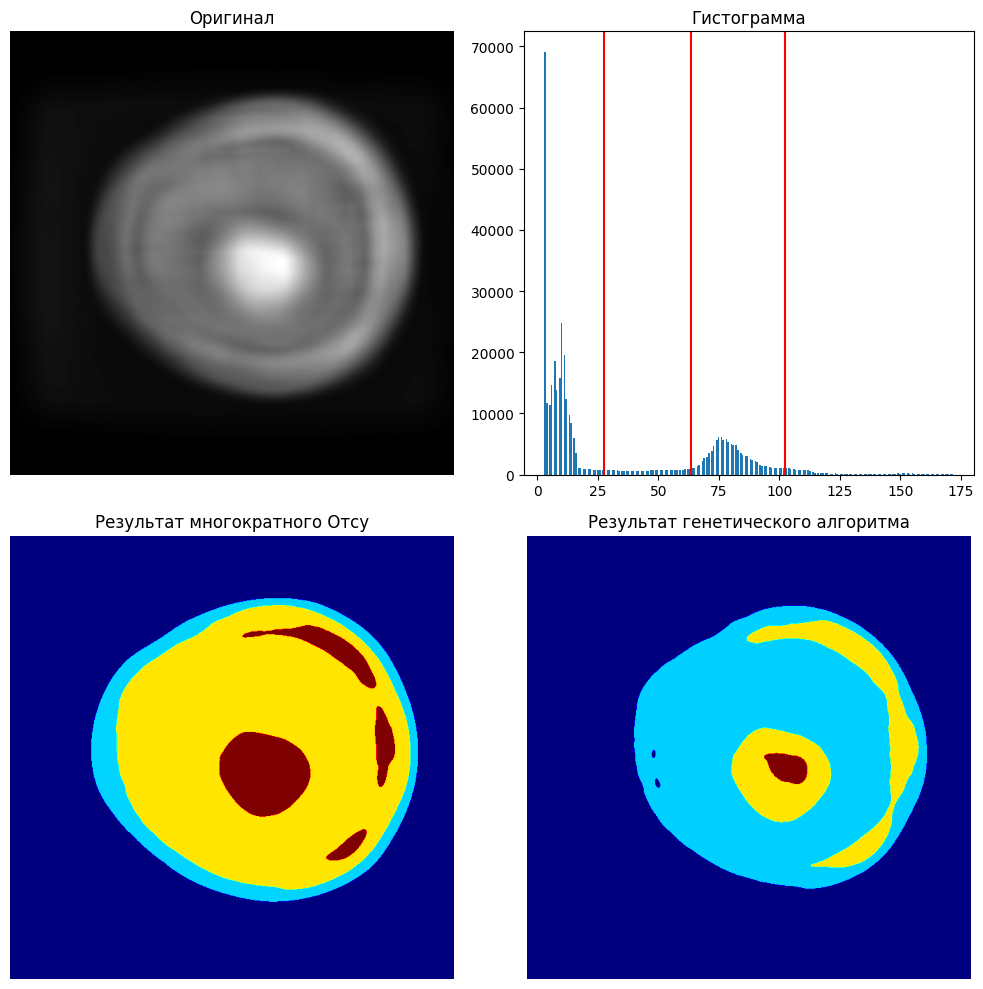

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  19.23670265178932
the ssim :  0.2945878689273654
Dice Similarity Coefficient :  0.01054538370650459
Jaccard Index :  0.3243220148634264


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.033581018447876 секунды


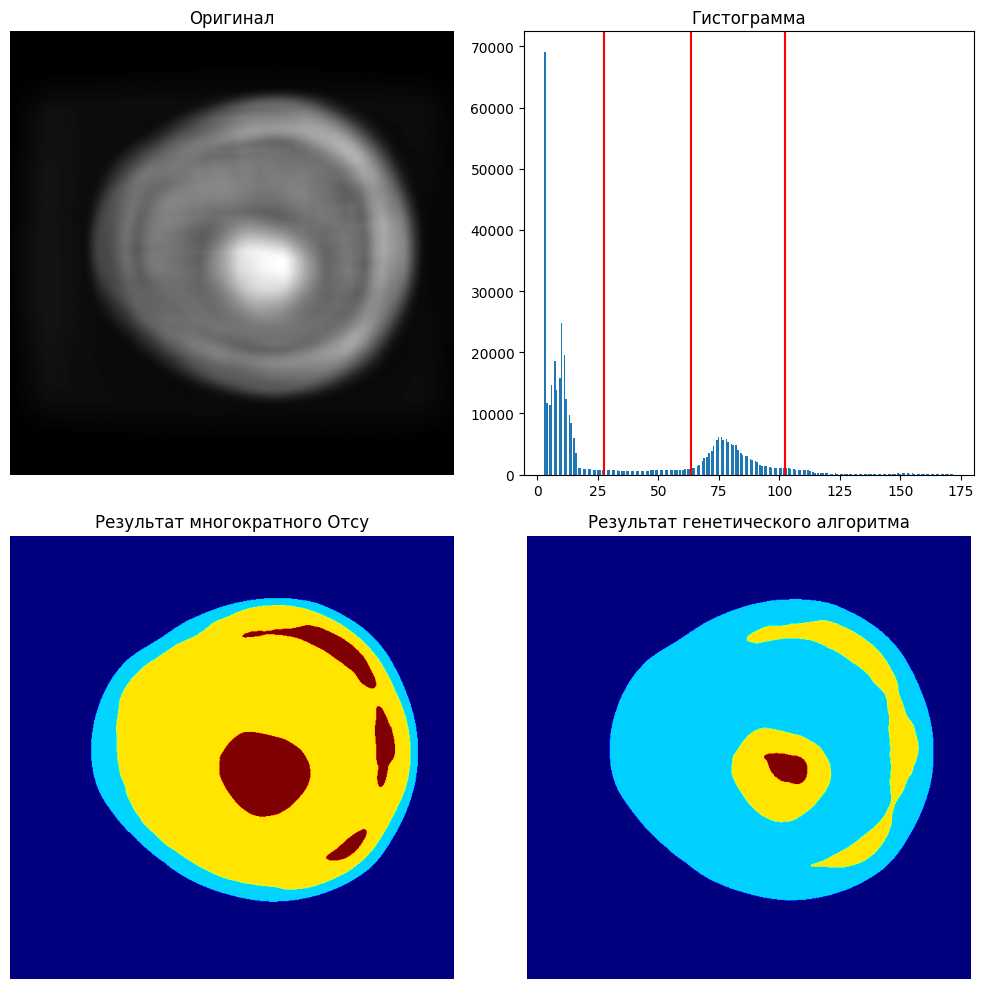

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  19.361098050029042
the ssim :  0.2986136746908712
Dice Similarity Coefficient :  0.011740255883883187
Jaccard Index :  0.3826355726130138


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.26806640625 секунды


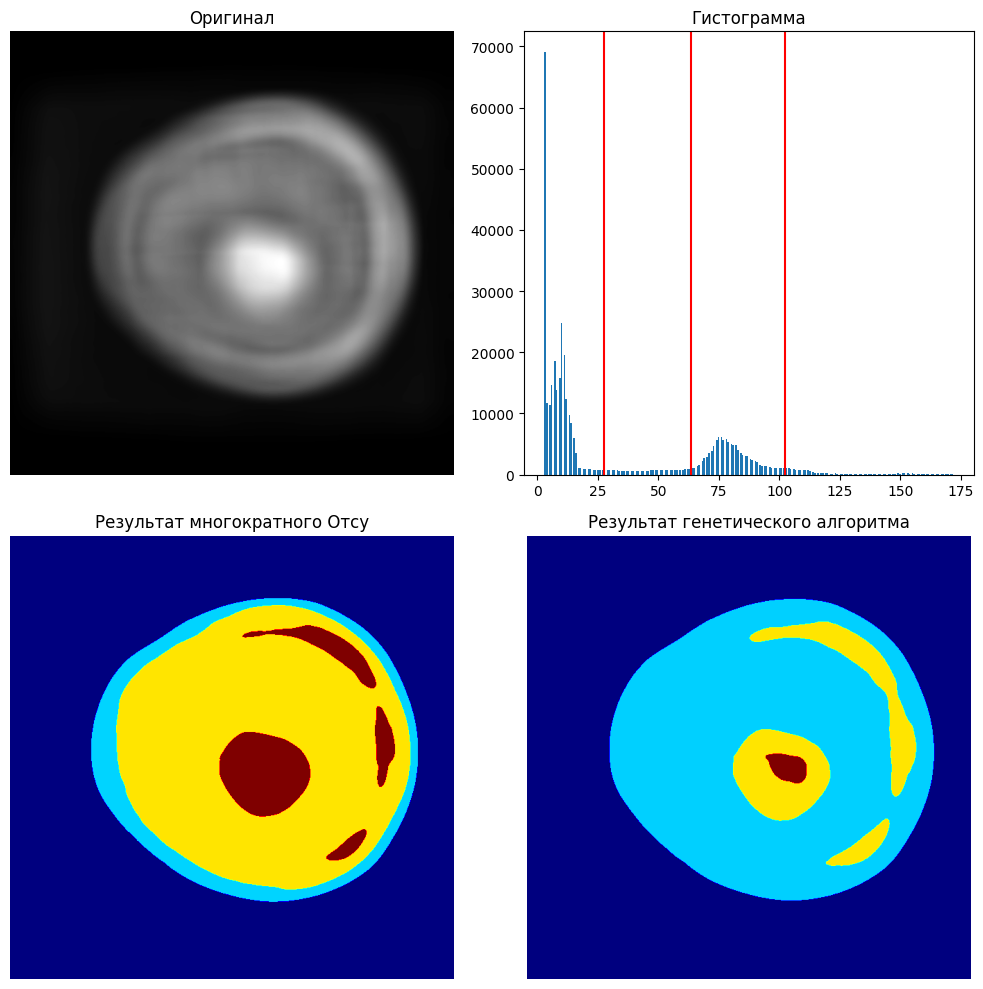

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  19.316048254993923
the ssim :  0.30131035101315
Dice Similarity Coefficient :  0.011853727770354242
Jaccard Index :  0.38432992509692476


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  18.19249987602234 секунды


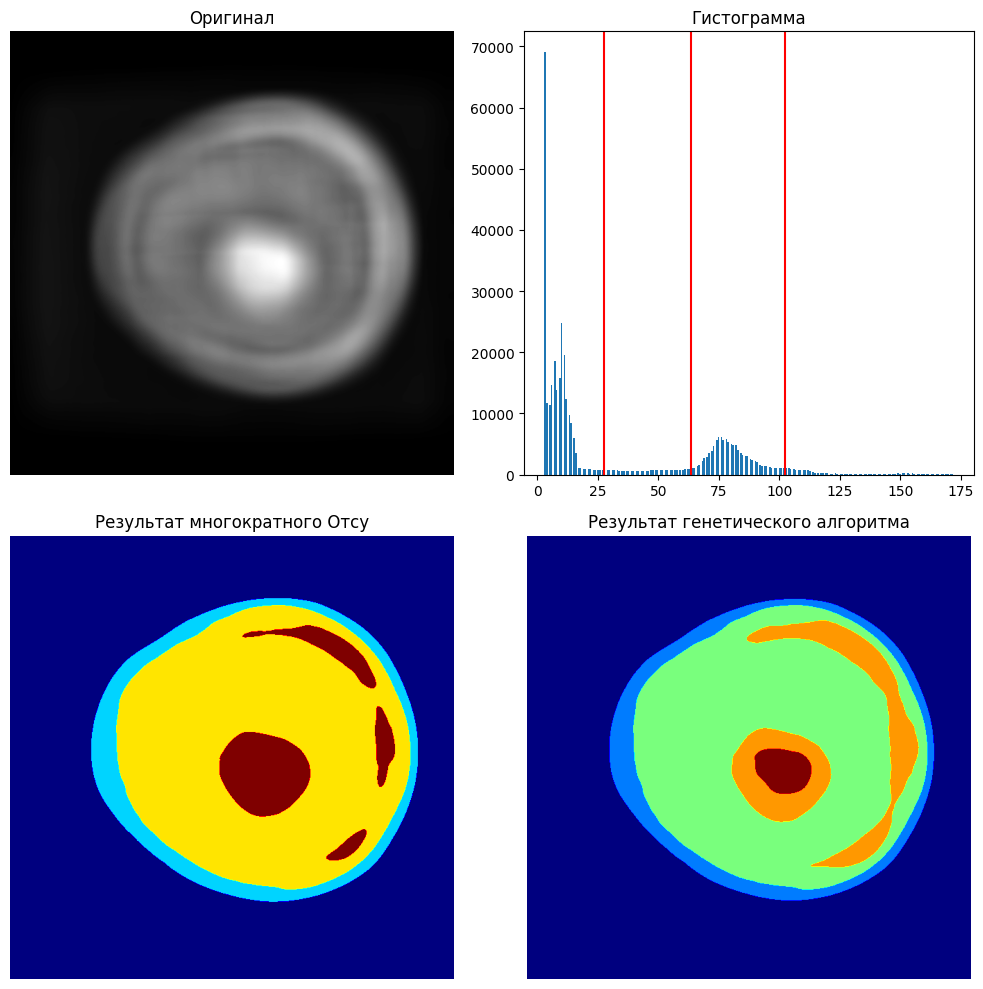

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  16.15835596216758
the ssim :  0.2880509439330516
Dice Similarity Coefficient :  0.008881235923668422
Jaccard Index :  0.38432992509692476


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.636040449142456 секунды


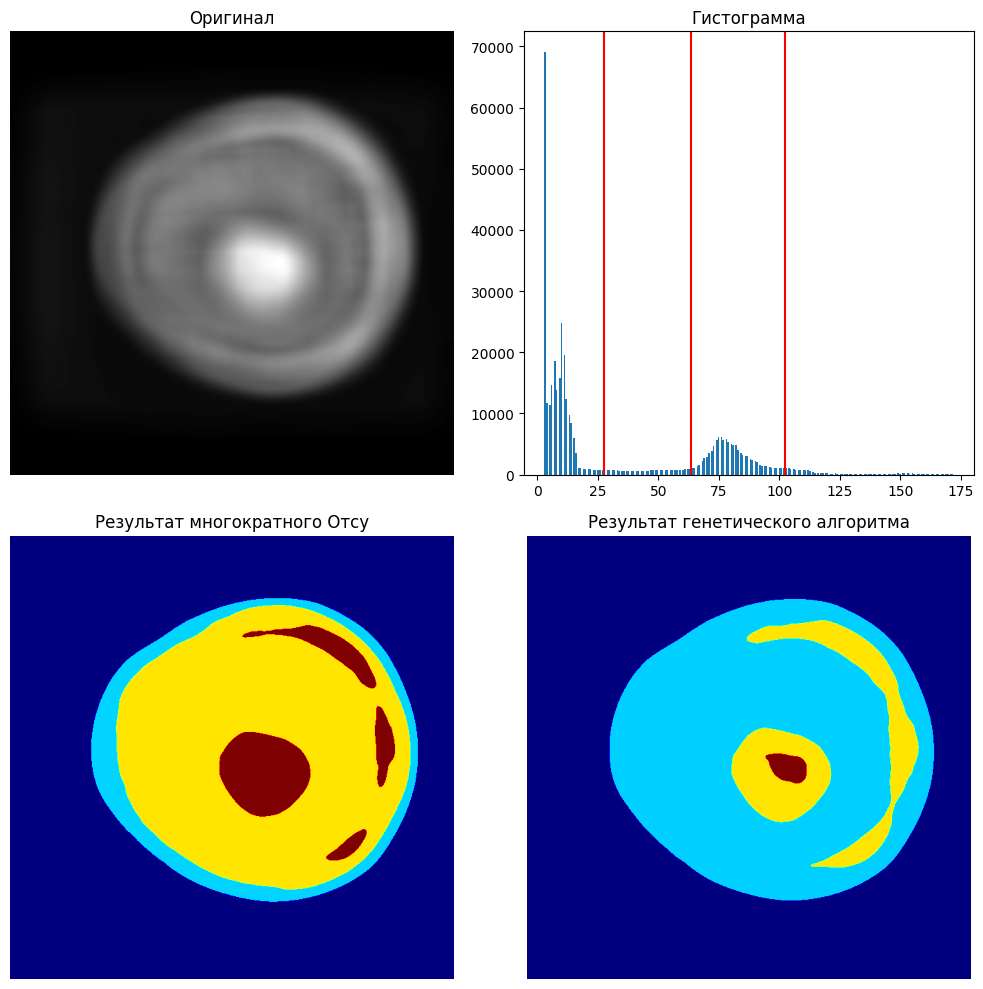

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  19.332517200770823
the ssim :  0.2990427472294728
Dice Similarity Coefficient :  0.011777501582821547
Jaccard Index :  0.38432992509692476


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.178302526474 секунды


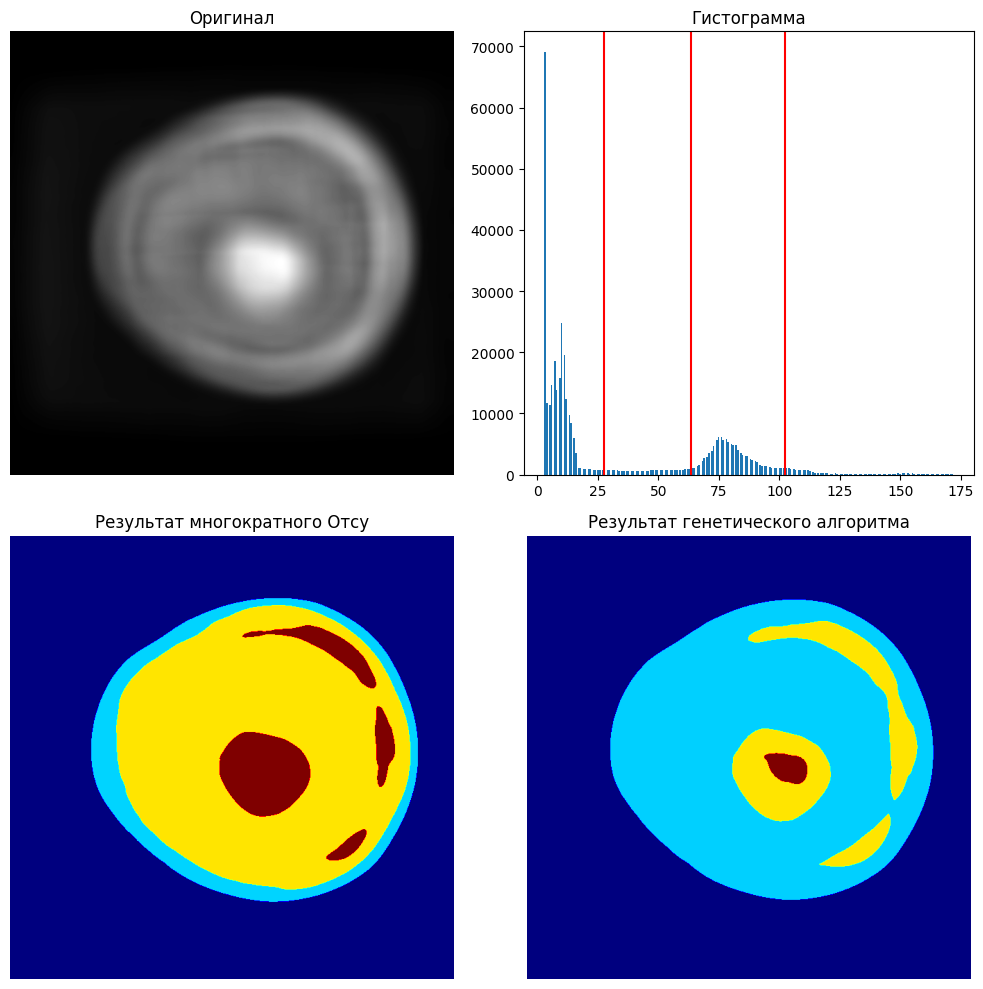

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  19.410648390628783
the ssim :  0.2990792666316379
Dice Similarity Coefficient :  0.011717447564018709
Jaccard Index :  0.37935917342942804


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.612832069396973 секунды


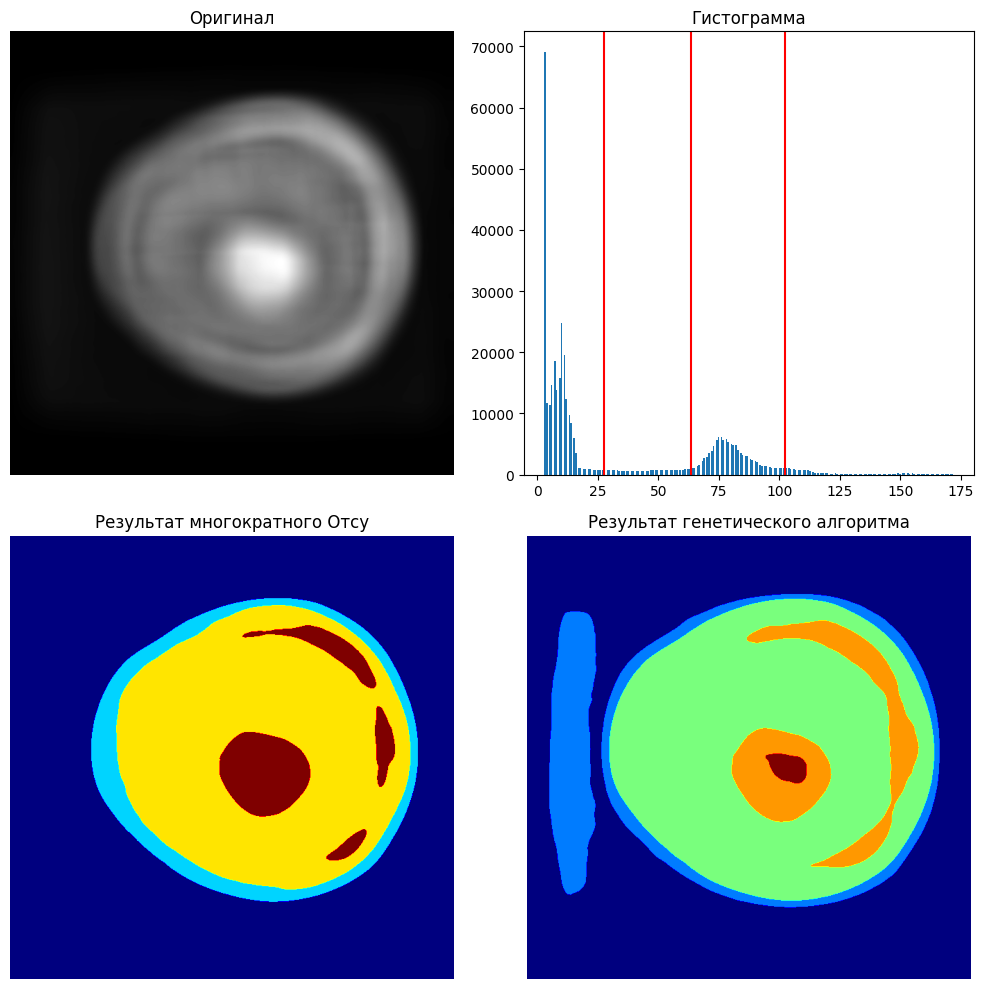

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  14.64280583948549
the ssim :  0.306192187031793
Dice Similarity Coefficient :  0.010057345615453524
Jaccard Index :  0.48321516811687615


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.93719506263733 секунды


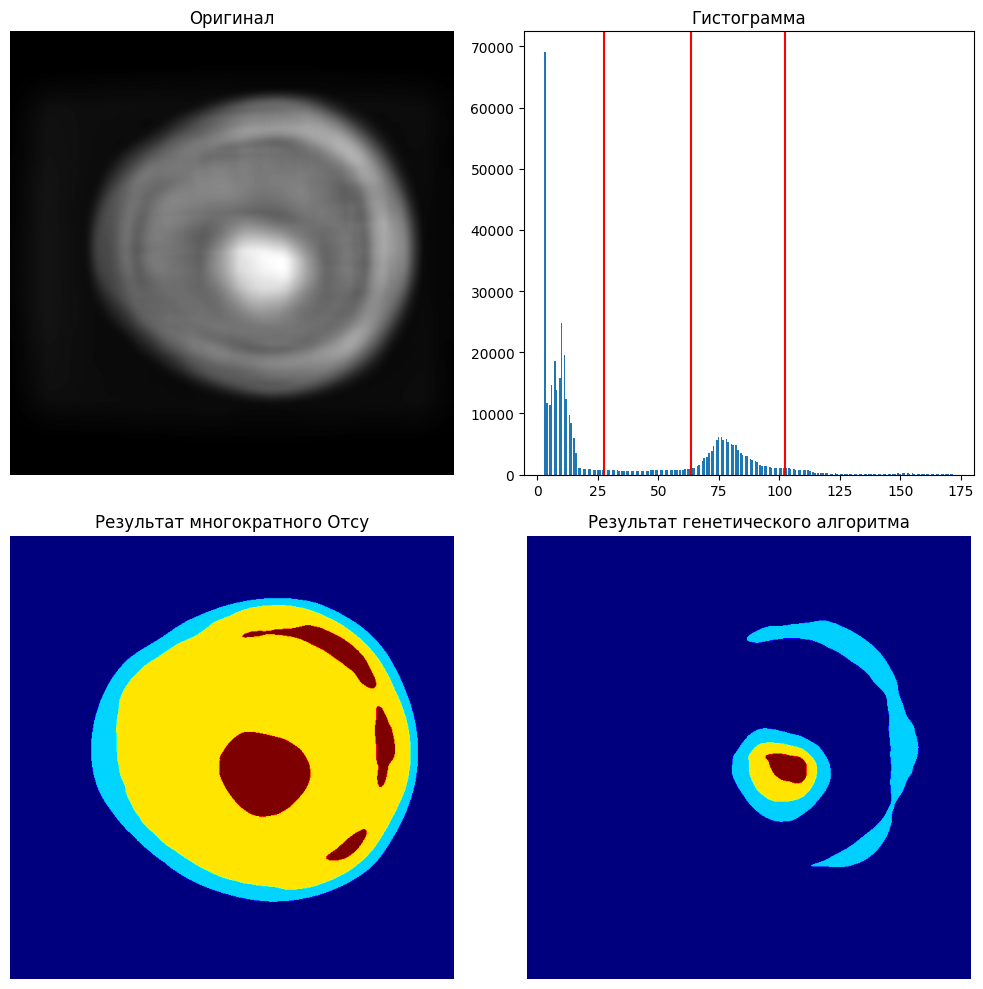

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  14.109782966726634
the ssim :  0.15321658005940286
Dice Similarity Coefficient :  0.003365293591482475
Jaccard Index :  0.07071358118731629


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.89353656768799 секунды


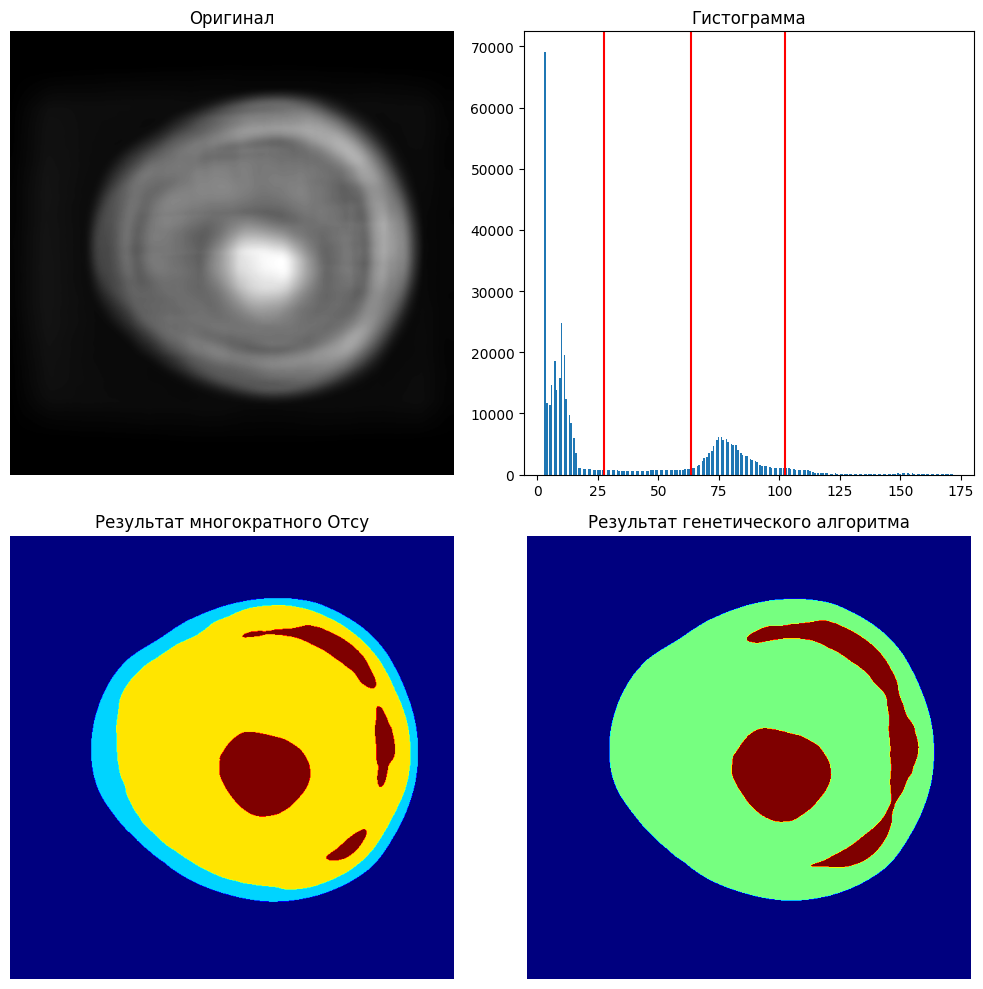

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  19.28673453499978
the ssim :  0.3005161553633725
Dice Similarity Coefficient :  0.011830068009364106
Jaccard Index :  0.38432992509692476


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476



Время, затраченное на оптимизацию генетического алгоритма:  17.78093433380127 секунды


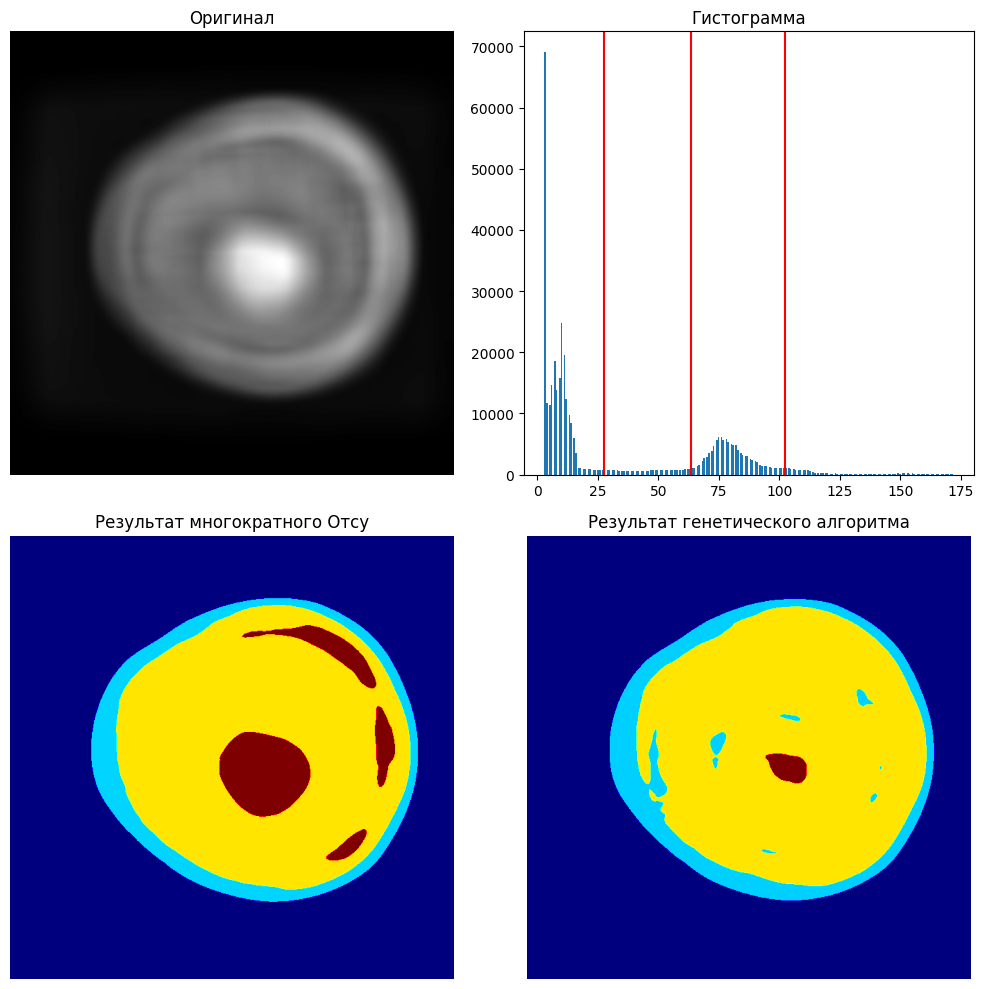

 ********* для генетического анализа изображений с пороговым значением ********* 

the psnr :  17.42480050763277
the ssim :  0.2907366215689959
Dice Similarity Coefficient :  0.009548632409527512
Jaccard Index :  0.38432992509692476


 ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* 

the psnr :  12.62825852907004
the ssim :  0.27470378372133514
Dice Similarity Coefficient :  0.007723455155376802
Jaccard Index :  0.39132462231076476





In [97]:
# Вычисляйте пороговые значения для нескольких Otsu вне цикла, поскольку они не меняются
thresholds = threshold_multiotsu(mean_filtered_image_57)
thresholded_image_multiotsuu = apply_multiotsu_thresholds(mean_filtered_image_57, thresholds)

for i in range(10):
    # Запустите генетический алгоритм для уточнения пороговых значений
    best_thresholdss = genetic_algorithm(mean_filtered_image_57, num_thresholds=4, 
                                    population_size=40, 
                                    num_generations=100, 
                                    mutation_rate=0.2)

    # Примените пороговые значения к изображению
    thresholded_image_geneticc = apply_multiotsu_thresholds(mean_filtered_image_57, best_thresholdss)

    # Отобразите исходное изображение, гистограмму, результат множественного Отсу и генетический результат
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

    # Исходное изображение
    ax[0, 0].imshow(mean_filtered_image_57, cmap='gray')
    ax[0, 0].set_title('Оригинал')
    ax[0, 0].axis('off')

    # Гистограмма с пороговыми линиями
    ax[0, 1].hist(mean_filtered_image_57.ravel(), bins=255)
    ax[0, 1].set_title('Гистограмма')
    for thresh in thresholdss:
        ax[0, 1].axvline(thresh, color='r')

    # Результат многократного Отсу
    ax[1, 0].imshow(thresholded_image_multiotsuu, cmap='jet')  
    ax[1, 0].set_title('Результат многократного Отсу')
    ax[1, 0].axis('off')

    # Результат генетического алгоритма
    ax[1, 1].imshow(thresholded_image_geneticc, cmap='jet')  
    ax[1, 1].set_title('Результат генетического алгоритма')
    ax[1, 1].axis('off')

    plt.tight_layout()
    plt.show()
    
    # Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient
    psnr_value_gf = psnr(image, thresholded_image_geneticc)
    ssim_value_gf = ssim(image, thresholded_image_geneticc)
    dsc_value_gf = dice_coefficient(image, thresholded_image_geneticc)
    ji_value_gf = jaccard_index(image, thresholded_image_geneticc)

    print(" ********* для генетического анализа изображений с пороговым значением ********* ")
    print()
    print("the psnr : ", psnr_value_gf)
    print("the ssim : ", ssim_value_gf)
    print("Dice Similarity Coefficient : ", dsc_value_gf)
    print("Jaccard Index : ", ji_value_gf)
    print()
    print()

    # Вычислите PSNR, SSIM, коэффициент Dice, индекс Жаккарда и Sorensen-Dice Coefficient
    psnr_valuee_of = psnr(image, thresholded_image_multiotsuu)
    ssim_valuee_of = ssim(image, thresholded_image_multiotsuu )
    dsc_valuee_of = dice_coefficient(image, thresholded_image_multiotsuu)
    ji_valuee_of = jaccard_index(image, thresholded_image_multiotsuu)

    print(" ********* для многопорогового метода ОЦУ с пороговым значением изображения ********* ")
    print()
    print("the psnr : ", psnr_valuee_of)
    print("the ssim : ",ssim_valuee_of)
    print("Dice Similarity Coefficient : ", dsc_valuee_of)
    print("Jaccard Index : ", ji_valuee_of)
    print()
    print()
    print()

In [98]:
num_thresholds = 6

Время, необходимое для работы функции multi otsu: 152.444189786911 секунды
Время, затраченное на оптимизацию генетического алгоритма:  0.579768180847168 секунды


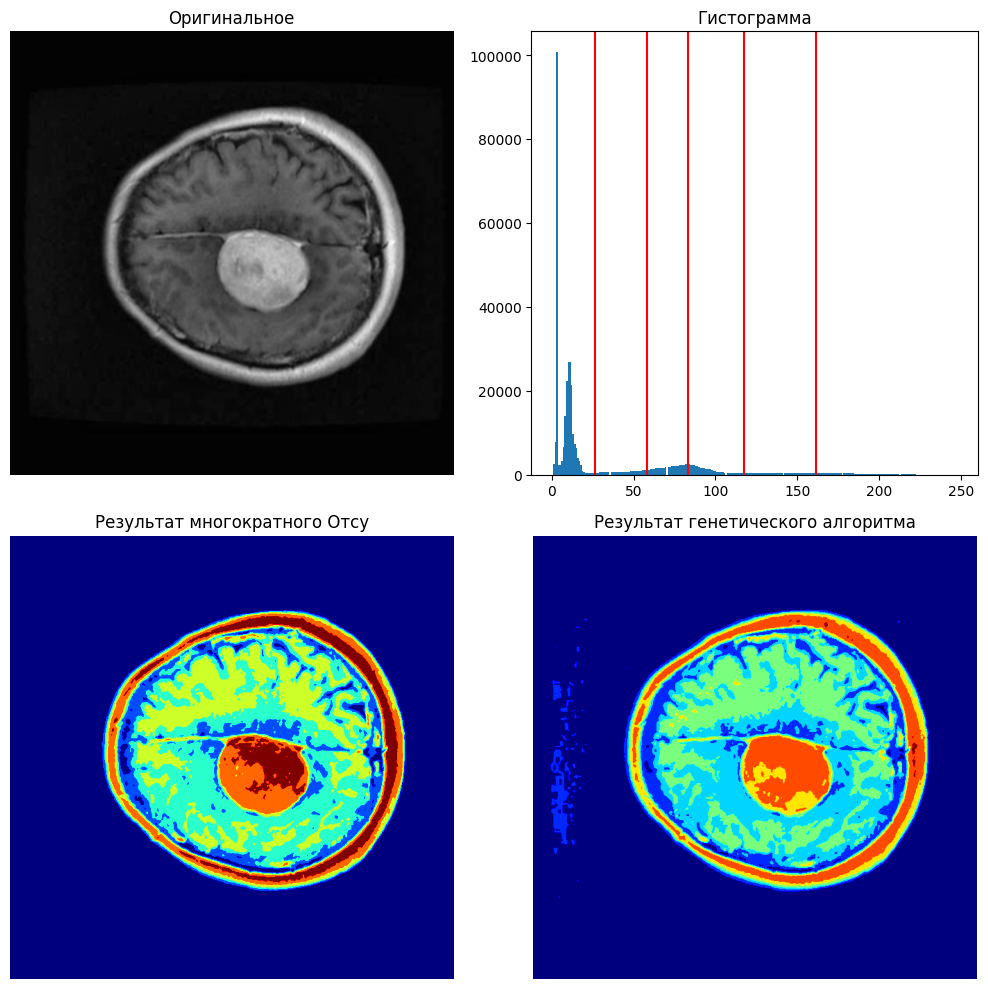

In [101]:
# Вычисление пороговых значений для нескольких Otsu
thresholds = threshold_multiotsu(image, classes=num_thresholds)

# Запустите генетический алгоритм для уточнения пороговых значений
best_thresholds = genetic_algorithm(image, num_thresholds)

# Примените пороговые значения к изображению
thresholded_image_multiotsu = apply_multiotsu_thresholds(image, thresholds)
thresholded_image_genetic = apply_multiotsu_thresholds(image, best_thresholds)

# Отобразите исходное изображение, гистограмму, результат множественного Отсу и генетический результат
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# Исходное изображение
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Оригинальное')
ax[0, 0].axis('off')

# Гистограмма с пороговыми линиями
ax[0, 1].hist(image.ravel(), bins=255)
ax[0, 1].set_title('Гистограмма')
for thresh in thresholds:
    ax[0, 1].axvline(thresh, color='r')

# Результат многократного Отсу
ax[1, 0].imshow(thresholded_image_multiotsu, cmap='jet')  
ax[1, 0].set_title('Результат многократного Отсу')
ax[1, 0].axis('off')

# Результат генетического алгоритма
ax[1, 1].imshow(thresholded_image_genetic, cmap='jet')  
ax[1, 1].set_title('Результат генетического алгоритма')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

Ну наверное, пока что хватит с этим алгоритмом... Может позже продолжу

In [100]:
import os
import cv2
import glob
import numpy as np

def process_image_set(image_dir, ground_truth_dir, method='otsu', num_classes=4):
    image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))
    ground_truth_paths = sorted(glob.glob(os.path.join(ground_truth_dir, '*.png')))

    dice_scores = []
    jaccard_scores = []

    for img_path, gt_path in zip(image_paths, ground_truth_paths):
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        ground_truth = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

        if method == 'otsu':
            thresholds = threshold_multiotsu(image, classes=num_classes)
        elif method == 'ga':
            thresholds = genetic_algorithm(image, num_thresholds=num_classes - 1)
        else:
            raise ValueError("Неизвестный метод: выберите 'otsu' или 'ga'")

        segmented = apply_multiotsu_thresholds(image, thresholds)
        # Бинаризация сегментации и маски для сравнения
        bin_segmented = (segmented > 0).astype(np.uint8)
        bin_gt = (ground_truth > 0).astype(np.uint8)

        dice = dice_coefficient(bin_segmented, bin_gt)
        jaccard = jaccard_index(bin_segmented, bin_gt)

        dice_scores.append(dice)
        jaccard_scores.append(jaccard)

        print(f"{os.path.basename(img_path)}: Dice={dice:.4f}, Jaccard={jaccard:.4f}")

    print(f"\nСреднее значение Dice: {np.mean(dice_scores):.4f}")
    print(f"Среднее значение Jaccard: {np.mean(jaccard_scores):.4f}")
